## Load data

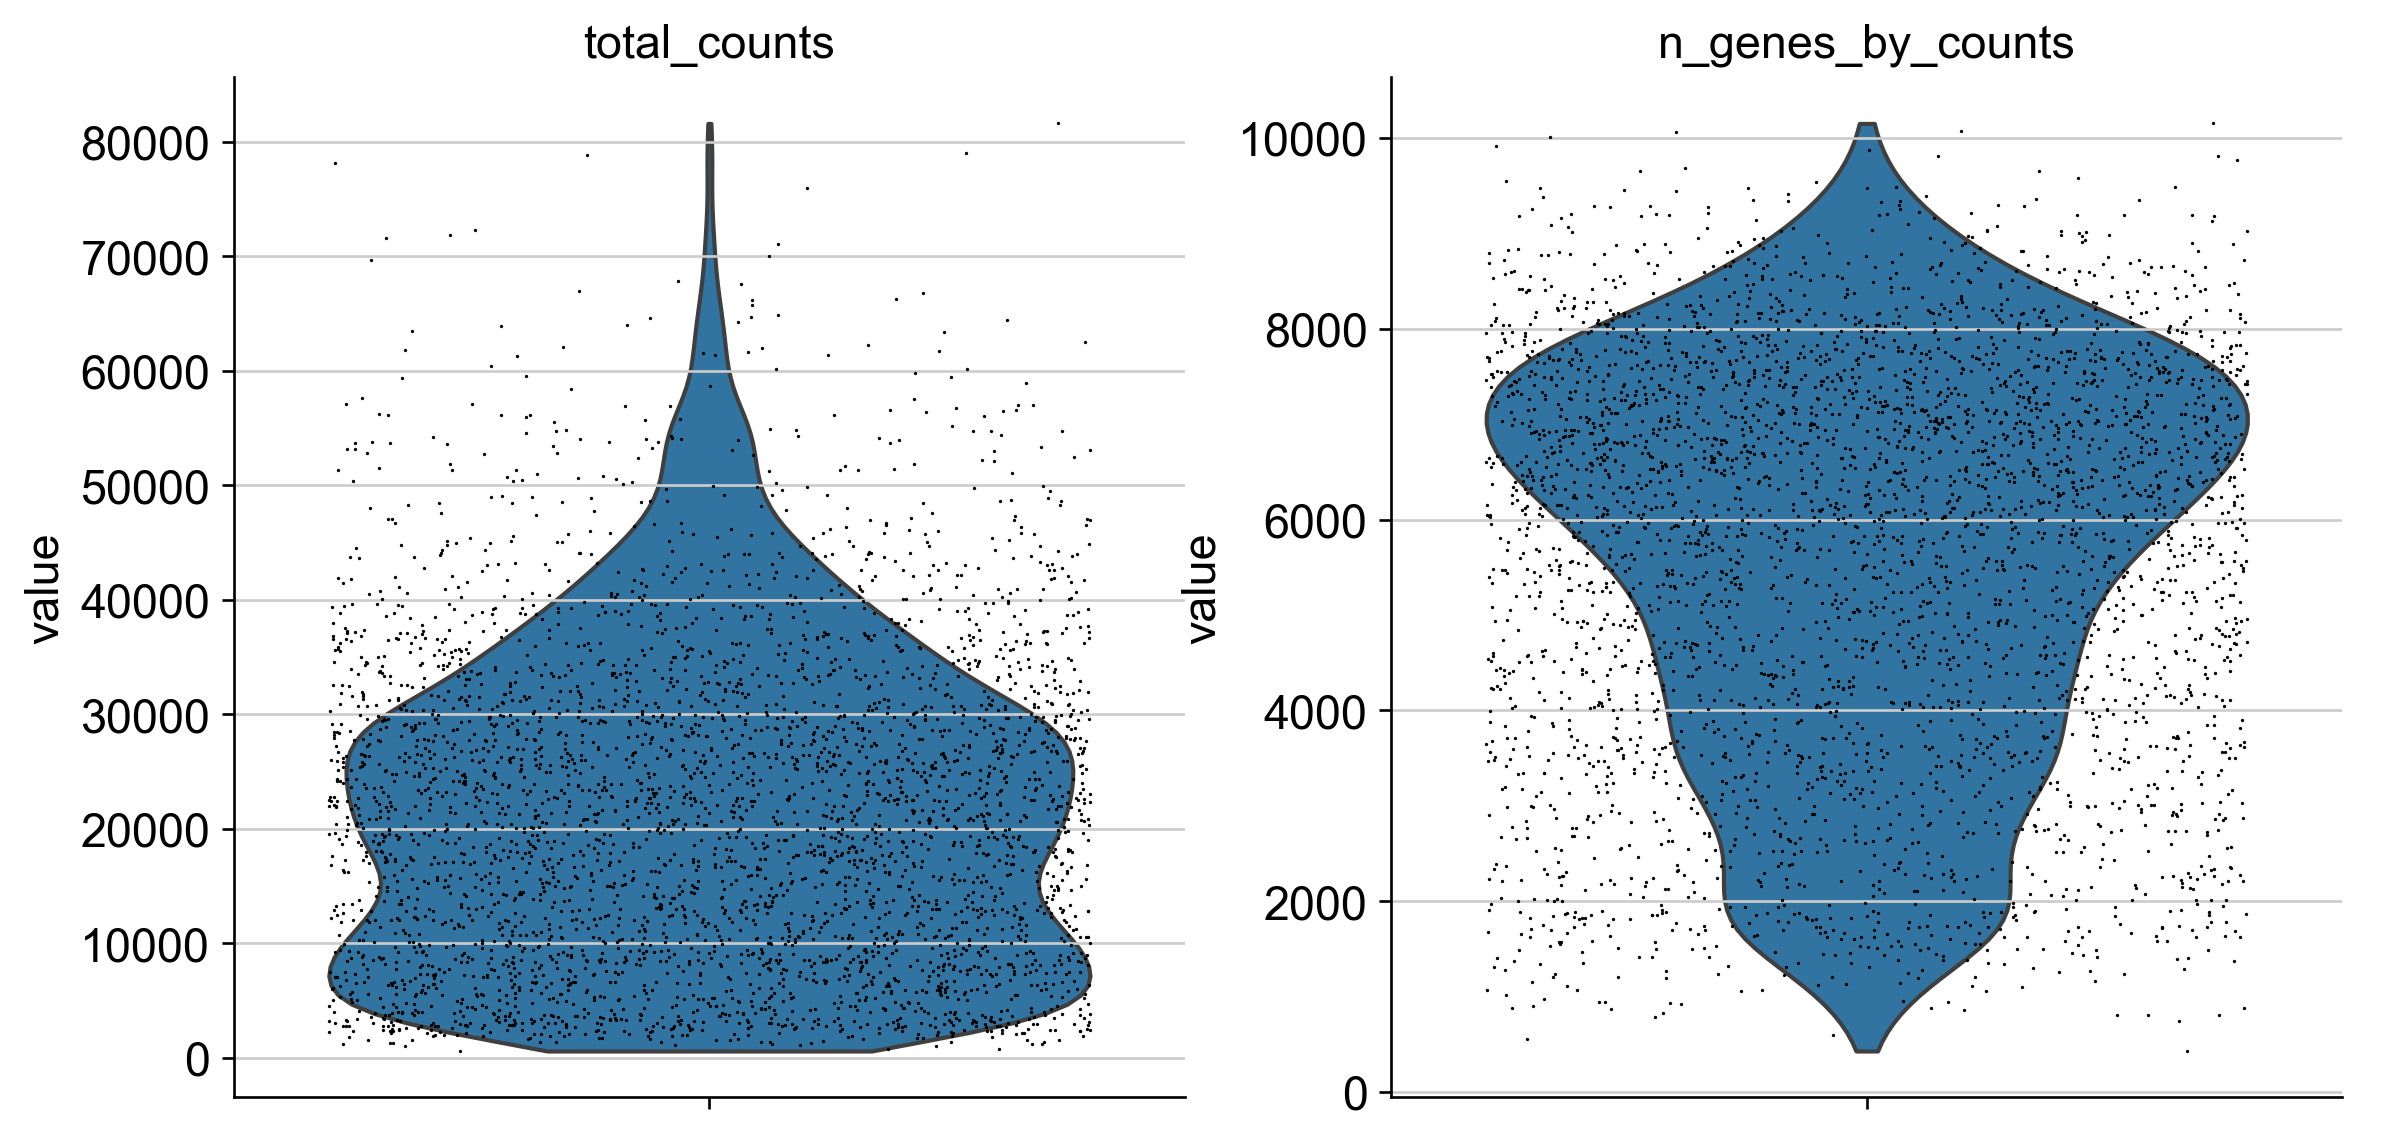

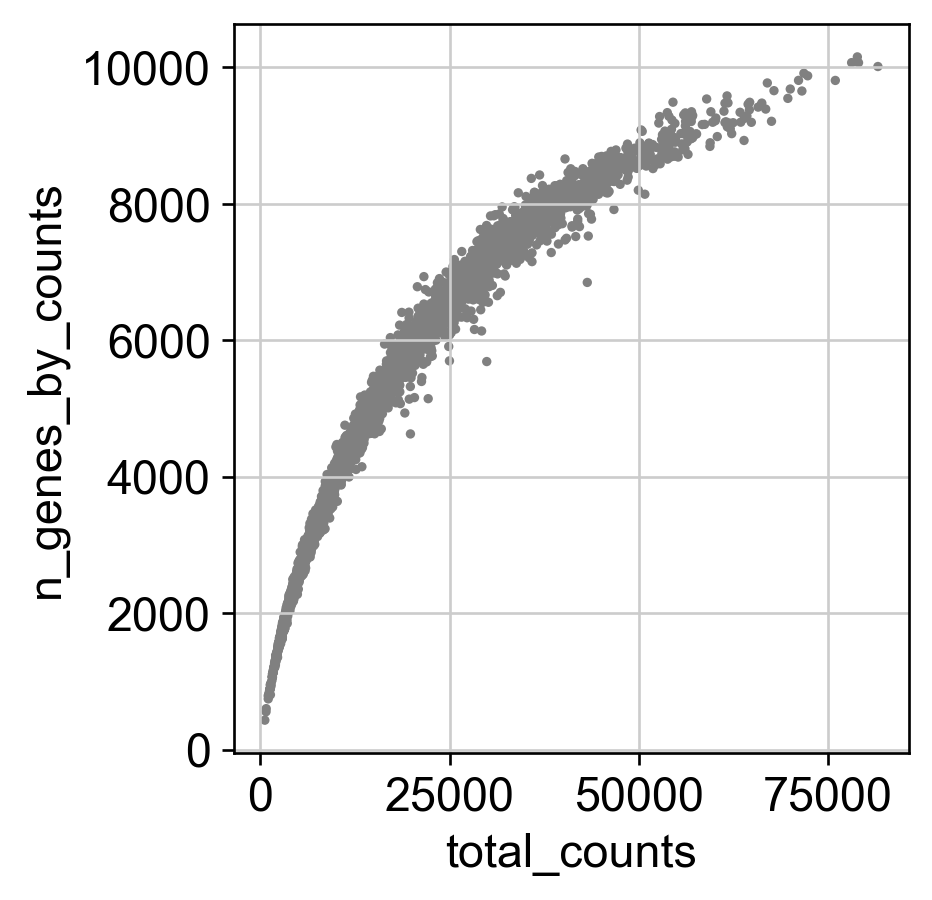

In [9]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

SAMPLE_ID = "V1_Breast_Cancer_Block_A_Section_1"
DATA_ROOT = Path("../data/raw")
DATA_DIR = DATA_ROOT / SAMPLE_ID
FIG_DIR = Path("../outputs/figures")

sc.settings.figdir = str(FIG_DIR)
sc.set_figure_params(dpi=120, facecolor="white")

DATA_ROOT.mkdir(parents=True, exist_ok=True)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Variable names are not unique")
    adata = sq.read.visium(path=DATA_DIR)

# Reload saved/raw object if needed
adata.var_names_make_unique()

# QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Basic QC plots
sc.pl.violin(
    adata,
    ["total_counts", "n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True
)

sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

## Filter low-quality spots


sc.pp.filter_cells(adata, min_counts=1000)
sc.pp.filter_genes(adata, min_cells=3)


## Normalize


In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Find variable genes:

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000)

## Run PCA

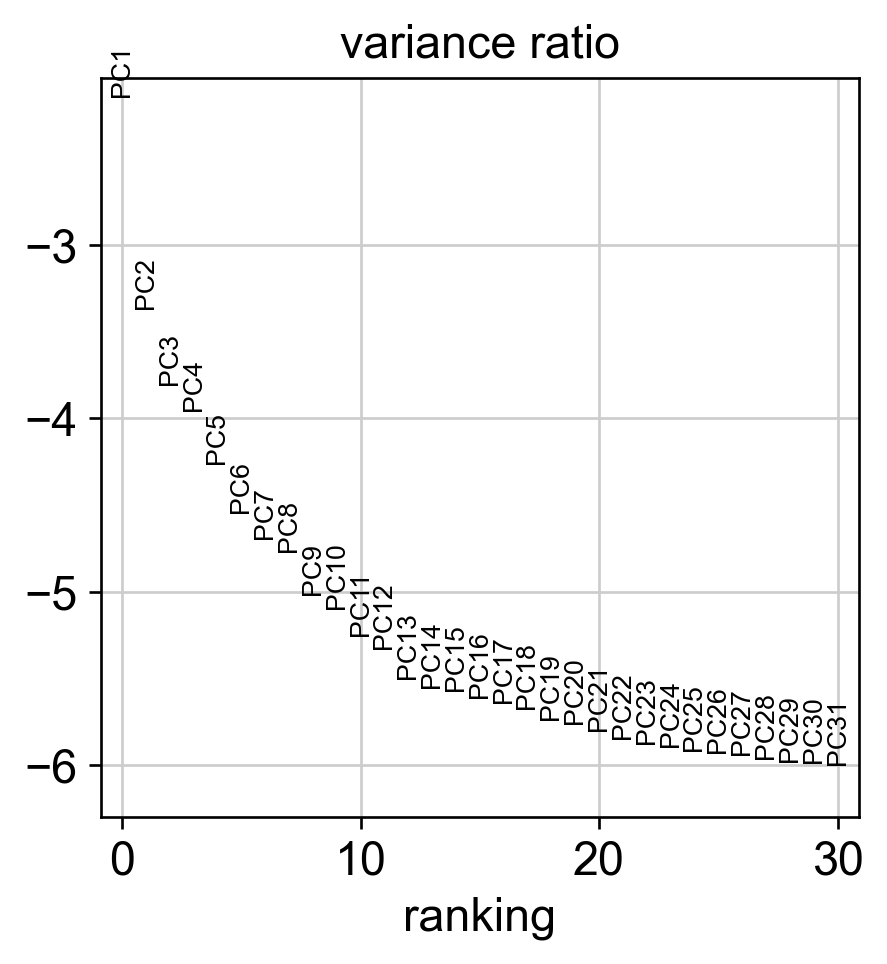

In [12]:
sc.pp.pca(adata)
sc.pl.pca_variance_ratio(adata, log=True)


## Save data

In [13]:
adata.write("../data/processed/breast_cancer_visium_qc.h5ad")